In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

In [2]:
df = pl.read_parquet("../final_patient_data.parquet")

In [3]:
df.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1


In [4]:
df = df.select([
    "patient_id", "hosp_admission_datetime", "death_date", "OMT_component_score"
])

In [5]:
df.head(1)

patient_id,hosp_admission_datetime,death_date,OMT_component_score
str,datetime[μs],date,i8
"""P001""",2018-07-04 11:15:00,2018-09-21,2


In [6]:
df = df.to_pandas()

In [7]:
# Convert to datetime and then extract the date only
# Normalize the time component to 00:00:00
df["hosp_admission_datetime"] = pd.to_datetime(df["hosp_admission_datetime"]).dt.normalize()
df["death_date"] = pd.to_datetime(df["death_date"]).dt.normalize()

In [8]:
# Create a one-year follow-up limit for each patient (admission date + 365 days)
df["one_year_limit"] = df["hosp_admission_datetime"]+pd.Timedelta(days=365)

In [9]:
df.head(1)

,patient_id,hosp_admission_datetime,death_date,OMT_component_score,one_year_limit
0,P001,2018-07-04,2018-09-21,2,2019-07-04


In [10]:
# Define the actual end of follow-up for each patient:
# use the death date if available; otherwise, use the one-year limit
df["end_followup"] = df["death_date"].fillna(df["one_year_limit"])

# If the death date is beyond the one-year limit, censor follow-up at the one-year limit
df.loc[df["end_followup"] > df["one_year_limit"], "end_followup"] = (df["one_year_limit"])

In [11]:
# 3. Calculate the elapsed follow-up time in days
# This is the time variable used in the Kaplan-Meier estimator
df["time"] = (
    df["end_followup"]-df["hosp_admission_datetime"]
).dt.days

In [12]:
# 4. Determine whether death occurred within this follow-up period
# This is the status/event variable
df["status"] = (df["death_date"].notna()) & (
    df["death_date"] < df["one_year_limit"]
)

In [13]:
df.head()

,patient_id,hosp_admission_datetime,death_date,OMT_component_score,one_year_limit,end_followup,time,status
0,P001,2018-07-04,2018-09-21,2,2019-07-04,2018-09-21,79,True
1,P002,2019-01-18,NaT,0,2020-01-18,2020-01-18,365,False
2,P003,2019-04-09,2020-12-04,2,2020-04-08,2020-04-08,365,False
3,P004,2018-03-03,NaT,1,2019-03-03,2019-03-03,365,False
4,P005,2019-02-01,2019-03-17,0,2020-02-01,2019-03-17,44,True


In [14]:
df_surv = df[['patient_id',  'time', 'status', 'OMT_component_score']].copy()

In [15]:
df_surv.head()

,patient_id,time,status,OMT_component_score
0,P001,79,True,2
1,P002,365,False,0
2,P003,365,False,2
3,P004,365,False,1
4,P005,44,True,0


In [16]:
df_surv[df_surv['time']<0]

,patient_id,time,status,OMT_component_score


In [17]:
df_surv = df_surv[df_surv['time']>= 0]

In [18]:
df_surv.isna().sum()

patient_id             0
time                   0
status                 0
OMT_component_score    0
dtype: int64

In [19]:
df_surv['OMT_component_score'].unique()

array([2, 0, 1], dtype=int8)

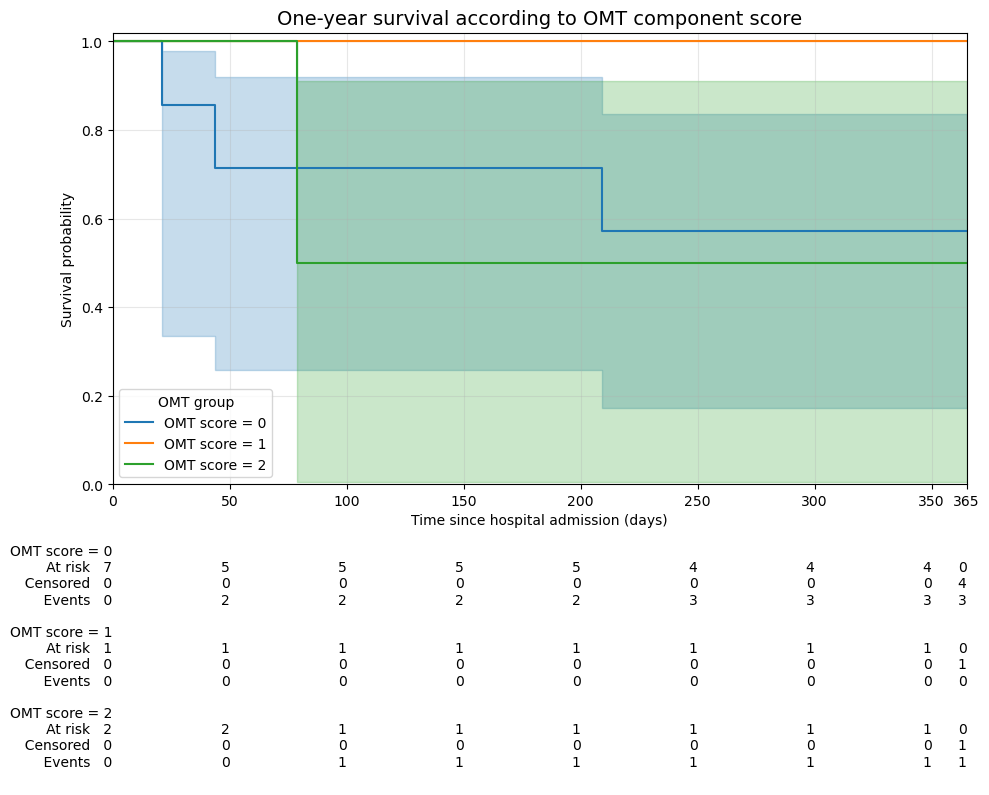

In [20]:
# Convert OMT score to integer
df_surv['OMT_component_score'] = (
    df_surv['OMT_component_score'].astype(int)
)


# Create the figure
fig, ax = plt.subplots(figsize=(10, 7))

# Store fitted Kaplan–Meier models
kmf_models = []


# Fit one Kaplan–Meier model for each OMT score
for omt_score in sorted(df_surv['OMT_component_score'].unique()):

    group = df_surv.loc[
        df_surv['OMT_component_score'] == omt_score
    ]

    kmf = KaplanMeierFitter()

    kmf.fit(
        durations=group['time'],
        event_observed=group['status'],
        label=f'OMT score = {omt_score}'
    )

    kmf.plot_survival_function(
        ax=ax,
        ci_show=True
    )

    # Save the fitted model for the at-risk table
    kmf_models.append(kmf)


# Define the time points shown on the plot and risk table
time_points = [0, 50, 100, 150, 200, 250, 300, 350, 365]

ax.set_xlim(0, 365)
ax.set_ylim(0, 1.02)
ax.set_xticks(time_points)

ax.set_title(
    'One-year survival according to OMT component score',
    fontsize=14
)

ax.set_xlabel('Time since hospital admission (days)')
ax.set_ylabel('Survival probability')

ax.grid(alpha=0.3)
ax.legend(title='OMT group')


# Add the at-risk table under the Kaplan–Meier plot
add_at_risk_counts(
    *kmf_models,
    ax=ax,
    xticks=time_points,
)


# Reserve enough space for the risk table
plt.tight_layout()
plt.subplots_adjust(bottom=0.30)

plt.show()

In [21]:
from lifelines.statistics import multivariate_logrank_test

result = multivariate_logrank_test(
    event_durations=df_surv['time'],
    groups=df_surv['OMT_component_score'],
    event_observed=df_surv['status']
)

print("Test statistic:", result.test_statistic)
print("P-value:", result.p_value)

Test statistic: 0.5545601357622525
P-value: 0.7578422201210953
